<a href="https://colab.research.google.com/github/madeelworks/Weapon-Detection/blob/model-integration/ReconEyeGun%2CGrenade%2CKnife%2CPistol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and Download Dataset

In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="GA8mVb1pzgEhTuBaJago")
project = rf.workspace("apsit").project("surveillance-gjosy")
version = project.version(3)
dataset = version.download("yolov8")




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Surveillance-3 in yolov8:: 100%|██████████| 13718/13718 [00:01<00:00, 7818.31it/s]


Check Location

In [2]:
print(dataset.location)


/content/Surveillance-3


Library

In [3]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.8/112.6 GB disk)


Train

In [ ]:
!pip install ultralytics --quiet

!pip install ultralytics --quiet

from ultralytics import YOLO
import os

dataset_path = "/content/Surveillance-3"
print("✅ Dataset path:", dataset_path)

model = YOLO('yolov8n.pt')

results = model.train(
    data=f"{dataset_path}/data.yaml",  # your dataset config file
        epochs=20,
            imgsz=640,
                batch=16,
                    name="weapon_detection_yolov8",
                        project="runs/train",
                            save=True,         # always save checkpoints
                                save_period=10,    # ✅ Save every 10 epochs
                                    device=0,          # use GPU if available
                                    )

                                    # --- STEP 6: Validate model performance ---
model.val()





✅ Dataset path: /content/Surveillance-3
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Surveillance-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=weapon_detection_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

test on Image

✅ Model loaded successfully!

image 1/1 /content/rifle.jpeg: 512x640 1 Pistol, 1 Rifle, 83.0ms
Speed: 2.6ms preprocess, 83.0ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)


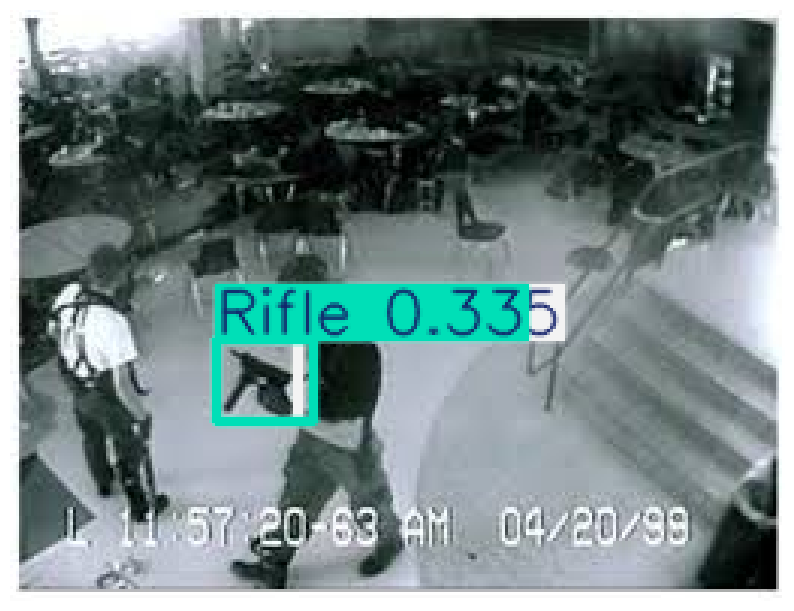

In [20]:
# --- STEP 1: Install YOLOv8 ---
!pip install ultralytics --quiet

# --- STEP 2: Import libraries ---
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# --- STEP 3: Load your trained model ---
model_path = "/content/runs/train/weapon_detection_yolov8/weights/best.pt"  # 👈 update if needed
model = YOLO(model_path)
print("✅ Model loaded successfully!")

# --- STEP 4: Choose an image to test ---
img_path = "/content/rifle.jpeg"  # 👈 replace with your image

# --- STEP 5: Run inference (no saving, only visualize) ---
results = model.predict(source=img_path, conf=0.25, save=False, show=False)

# --- STEP 6: Display the image with bounding boxes inline ---
for result in results:
    # Draw bounding boxes and labels on the image
        annotated_img = result.plot()  # returns a NumPy array (BGR)

                # Convert from BGR to RGB for matplotlib display
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()


Video Testing

In [ ]:
# --- STEP 1: Install YOLOv8 ---
!pip install ultralytics --quiet

# --- STEP 2: Import libraries ---
from ultralytics import YOLO
import cv2

# --- STEP 3: Load your trained model ---
model_path = "/content/runs/train/weapon_detection_yolov8/weights/best.pt"  # 👈 change if different
model = YOLO(model_path)

# --- STEP 4: Define your video path ---
video_path = "/content/video.mp4"   # 👈 update this with your test video path
output_path = "/content/output_detected.mp4"  # where to save the results

# --- STEP 5: Run inference on the video ---
results = model.predict(
    source=video_path,     # can be path, webcam index (0), or URL
        conf=0.25,              # confidence threshold (adjust as needed)
            save=True,             # save the annotated video
                project="runs/video_test",  # output folder
                    name="weapon_test",         # subfolder name
                        show=False,                 # show live preview (may not work in Colab)
                            stream=False                # stream mode off for simplicity
                            )

                            # --- STEP 6: Locate saved output ---
print("✅ Inference complete!")
print("📁 Output video saved at:")
print(results[0].save_dir)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3516) /content/video.mp4: 384x640 (no detections), 8.1ms
video 1/1 (frame 2/3516) /content/video.mp4: 384x640 (no detections), 6.2ms
video 1/1 (frame 3/3516) /content/video.mp4: 384x640 (no detections), 5.9ms
video 1/1 (frame 4/3516) /content/video.mp4: 384x640 (no detections), 6.3ms
video 1/1 (frame 5/3516) /content/video.mp4: 384x640 (no detections), 5.7ms
video 1/1 (frame 6/3516) /content/video.mp4: 384x640 (no detections), 6.1ms


In [6]:
!rm -rf /content/*


Check if every image has a label

In [8]:
from glob import glob
import os

images = glob("/content/Surveillance-3/train/images/*.jpg")
labels = glob("/content/Surveillance-3/train/labels/*.txt")

print(f"Images: {len(images)}, Labels: {len(labels)}")

missing = [os.path.basename(i) for i in images if not os.path.exists(
    i.replace("/images/", "/labels/").replace(".jpg", ".txt")
    )]

print(f"Missing labels: {len(missing)}")

print(missing[:20])



Images: 4797, Labels: 4797
Missing labels: 0
[]


Rename the labels

In [9]:
import os
label_dir = "/content/Surveillance-3/train/labels"

empty_labels = [f for f in os.listdir(label_dir) if os.path.getsize(os.path.join(label_dir, f)) == 0]

print(f"Empty labels: {len(empty_labels)}")
if empty_labels:
    print(empty_labels[:10])  # show first 10 empty label files




Empty labels: 0


Check Bounding Box Size

In [10]:
import pandas as pd
import glob

sizes = []

for label_file in glob.glob("/content/Surveillance-3/train/labels/*.txt"):
    with open(label_file) as f:
            for line in f:
                        parts = line.strip().split()
if len(parts) == 5:  # class, x, y, w, h
 _, x, y, w, h = map(float, parts)
sizes.append(w * h)

print("✅ Total boxes found:", len(sizes))
if sizes:
 sizes = pd.Series(sizes)
 print(sizes.describe())
else:
 print("⚠️ No valid boxes found. Check label files.")





✅ Total boxes found: 1
count    1.000000
mean     0.320334
std           NaN
min      0.320334
25%      0.320334
50%      0.320334
75%      0.320334
max      0.320334
dtype: float64


Check Class Imbalance

In [11]:
from collections import Counter
import glob

counter = Counter()

# Loop through all YOLO label files
for f in glob.glob("/content/Surveillance-3/train/labels/*.txt"):
    with open(f, "r") as file:
            for line in file:
                        parts = line.strip().split()
            if len(parts) >= 1:
             cls = int(parts[0])
             counter[cls] += 1  # correctly indented inside the loop

                                                                    # Print summary
             print("✅ Class distribution:")
             for cls_id, count in sorted(counter.items()):
              print(f"Class {cls_id}: {count} boxes")

                                                                        # Optional: check for imbalance ratio
if len(counter) > 1:
 max_cls = max(counter, key=counter.get)
 min_cls = min(counter, key=counter.get)
 ratio = counter[max_cls] / counter[min_cls]
print(f"\n Imbalance ratio (max/min): {ratio:.2f}x")




✅ Class distribution:
Class 3: 1 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 3: 1 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 1 boxes
Class 3: 1 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 2 boxes
Class 3: 1 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 3 boxes
Class 3: 1 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 3 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 3 boxes
Class 2: 1 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 4 boxes
Class 2: 1 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 1 boxes
Class 1: 5 boxes
Class 2: 1 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 2 boxes
Class 1: 5 boxes
Class 2: 1 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 2 boxes
Class 1: 5 boxes
Class 2: 2 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 2 boxes
Class 1: 6 boxes
Class 2: 2 boxes
Class 3: 2 boxes
✅ Class distribution:
Class 0: 2 boxes
Class 1: 6 boxes
Class 2: 2 boxes


In [12]:
import pandas as pd
import glob
import os

label_files = glob.glob("/content/Surveillance-3/train/labels/*.txt")
print(f"📁 Total label files found: {len(label_files)}")

sizes = []
empty_files = 0
valid_files = 0

for label_file in label_files:
    with open(label_file) as f:
        lines = f.readlines()
        if not lines:  # Empty file
            empty_files += 1
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:  # class, x, y, w, h
                _, x, y, w, h = map(float, parts)
                sizes.append(w * h)
                valid_files += 1

print(f"📊 Summary:")
print(f"   Label files: {len(label_files)}")
print(f"   Empty files: {empty_files}")
print(f"   Valid boxes: {len(sizes)}")
print(f"   Files with objects: {valid_files}")

if sizes:
    sizes_series = pd.Series(sizes)
    print("\n📏 Bounding Box Statistics:")
    print(sizes_series.describe())

    # Check if sizes are reasonable (should be between 0 and 1 for YOLO format)
    print(f"\n🔍 Size range check:")
    print(f"   Min size: {min(sizes):.6f}")
    print(f"   Max size: {max(sizes):.6f}")
    print(f"   Within 0-1 range: {all(0 <= s <= 1 for s in sizes)}")

📁 Total label files found: 4797
📊 Summary:
   Label files: 4797
   Empty files: 0
   Valid boxes: 6871
   Files with objects: 6871

📏 Bounding Box Statistics:
count    6871.000000
mean        0.172471
std         0.208440
min         0.000011
25%         0.020212
50%         0.094204
75%         0.244473
max         1.000000
dtype: float64

🔍 Size range check:
   Min size: 0.000011
   Max size: 1.000000
   Within 0-1 range: True
